# Empirical Rating Model

Ratings built from the observed distribution of each statistic rather than from
the hand-set coefficients in `train_player_params.py`.

**WTA and ATP are kept separate throughout.** The two tours differ enough on the
serve/return split that pooling them would push every WTA player's return rating
up and every ATP player's down for reasons that have nothing to do with skill.
The gap is quantified at the bottom of this section.

Data comes from `sportradar_data.py` (Sportradar Tennis v3), the same source as
`historical_data_analysis.ipynb`, served from `sportradar_cache/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sportradar_data import Client, load_match_stats

pd.set_option('display.max_columns', None)

today_dt = pd.to_datetime('today')
start_date = (today_dt - pd.DateOffset(years=1)).date()
end_date = today_dt.date()

client = Client(budget=520)
all_matches = load_match_stats(start_date, end_date, client=client, tour_only=True,
                               include_challengers=True)

print(f'{len(all_matches)} player-match rows over {all_matches["match_id"].nunique()} matches '
      f'({start_date} to {end_date}, {client.requests_made} live API calls)')

42182 player-match rows over 21342 matches (2025-08-26 to 2026-08-26, 0 live API calls)


## 1. Rate distributions per tour

Eight rates, each a ratio of two counted columns. `ace_rate` and `df_rate` are
also carried in log10 form with a **5e-2 offset** -- both are bounded below by
zero and heavily right-skewed, and the offset keeps `log10` finite for the
players who hit none.

In [2]:
# Separate offsets: each only has to clear that rate's own zero floor.
# ace_rate averages 0.033-0.082, so 5e-2 is the right order of magnitude.
# df_rate averages 0.035, where a 5e-2 offset would exceed the signal itself
# and flatten the transform back to near-linear -- 5e-3 keeps the shape.
# Qualifying draws are easier than the main draws they feed, and ranking points
# barely register it -- a qualifier's median opponent sits near 880 points
# against ~1000 for a main-draw regular, about 0.06 of opp_adj. So qualifying
# matches take a flat penalty on top.
#
# A penalty, not a row weight: down-weighting was tried and moved players the
# wrong way. opp_adj already docks qualifying rows (0.35 points for Spizzirri),
# so shrinking their influence *removed* that discount and raised his rating.
# Subtracting deepens the discount instead of discarding it.
QUALIFYING_PENALTY_Z = 1.0

# The second tier of each tour, under the two names the feed uses for the same
# thing: the ATP calls it Challenger, the WTA calls it 125. Penalising only the
# ATP one would rebuild the asymmetry in the opposite direction.
SECOND_TIER_LEVELS = {'challenger', 'wta_125'}
TIER_PENALTY_Z = 1.0

# No double jeopardy: the two penalties are combined with max(), not sum, so a
# qualifying match at a Challenger costs 1z rather than 2z. Qualifying at a
# Challenger is not twice as easy as either on its own.
Z_IN_RATING_POINTS = 2.0

ACE_OFFSET = 5e-2
DF_OFFSET = 5e-3

def add_rates(df):
    """The eight tuning rates, plus log10 versions of the two skewed ones."""
    df = df.copy()
    total_pts = df['serve_pts'] + df['return_pts']

    df['ace_rate']                  = df['aces']           / df['serve_pts']
    df['first_serve_in_rate']       = df['first_in']       / df['serve_pts']
    df['df_rate']                   = df['dfs']            / df['serve_pts']
    df['first_serve_pts_win_rate']  = df['first_won']      / df['first_in']
    df['second_serve_pts_win_rate'] = df['second_won']     / df['second_in']
    df['break_pts_save_rate']       = df['bp_saved']       / df['bk_pts']
    df['return_pts_win_rate']       = df['return_pts_won'] / df['return_pts']
    df['winner_rate']               = df['winners']        / total_pts
    df['unforced_error_rate']       = df['unforced']       / total_pts

    df[RATES] = df[RATES].replace([np.inf, -np.inf], np.nan)

    df['is_qualifying'] = df['round'].astype(str).str.contains('qualification', case=False)
    df['is_second_tier'] = df['level'].isin(SECOND_TIER_LEVELS)
    df['penalty_z'] = np.maximum(
        QUALIFYING_PENALTY_Z * df['is_qualifying'],
        TIER_PENALTY_Z * df['is_second_tier'],
    )

    # log10 with an additive offset: both rates bottom out at 0 for players who
    # hit no aces / no double faults, which log10 alone cannot represent.
    df['log_ace_rate'] = np.log10(df['ace_rate'] + ACE_OFFSET)
    df['log_df_rate']  = np.log10(df['df_rate']  + DF_OFFSET)
    return df


RATES = [
    'ace_rate',
    'df_rate',
    'first_serve_in_rate',
    'first_serve_pts_win_rate',
    'second_serve_pts_win_rate',
    'break_pts_save_rate',
    'return_pts_win_rate',
    'winner_rate',
    'unforced_error_rate',
]
LOG_RATES = ['log_ace_rate', 'log_df_rate']

# The point count each rate is measured over. Needed to work out how much of a
# player's match-to-match spread is just sampling noise.
RATE_DENOM = {
    'ace_rate':                  'serve_pts',
    'df_rate':                   'serve_pts',
    'first_serve_in_rate':       'serve_pts',
    'first_serve_pts_win_rate':  'first_in',
    'second_serve_pts_win_rate': 'second_in',
    'break_pts_save_rate':       'bk_pts',
    'return_pts_win_rate':       'return_pts',
    'winner_rate':               'total_pts',
    'unforced_error_rate':       'total_pts',
}

wta = add_rates(all_matches[all_matches['gender'] == 'women'].reset_index(drop=True))
atp = add_rates(all_matches[all_matches['gender'] == 'men'].reset_index(drop=True))

print(f'WTA: {len(wta):>6} rows over {wta["match_id"].nunique():>5} matches')
print(f'ATP: {len(atp):>6} rows over {atp["match_id"].nunique():>5} matches')

WTA:  11357 rows over  5905 matches
ATP:  30825 rows over 15437 matches


In [3]:
def rate_summary(df, label):
    """Mean and standard deviation of every rate, on this tour alone."""
    cols = RATES + LOG_RATES
    out = pd.DataFrame({
        'n':    df[cols].notna().sum(),
        'mean': df[cols].mean(),
        'std':  df[cols].std(),
        'min':  df[cols].min(),
        'max':  df[cols].max(),
    })
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out

wta_summary = rate_summary(wta, 'WTA')
atp_summary = rate_summary(atp, 'ATP')

summary = wta_summary.join(atp_summary)
display(summary.round(4))

WTA                                    ATP  \
                               n    mean     std     min     max      n   
ace_rate                   11354  0.0332  0.0371  0.0000  0.3409  30694   
df_rate                    11354  0.0515  0.0369  0.0000  0.4074  30694   
first_serve_in_rate        11353  0.6586  0.1057  0.0000  1.0000  30694   
first_serve_pts_win_rate   11352  0.6178  0.1154  0.0000  1.0000  30693   
second_serve_pts_win_rate  11316  0.4430  0.1406  0.0000  1.0000  30698   
break_pts_save_rate        11094  0.5134  0.2261  0.0000  1.0000  29203   
return_pts_win_rate        11354  0.4420  0.0998  0.0000  1.0000  30694   
winner_rate                  890  0.1455  0.0577  0.0339  0.4188    862   
unforced_error_rate          889  0.1898  0.0633  0.0353  0.4667    862   
log_ace_rate               11354 -1.1141  0.1651 -1.3010 -0.4079  30694   
log_df_rate                11354 -1.3674  0.3700 -2.3010 -0.3847  30694   

                                                           
                             mean     std     min     max  
ace_rate                   0.0634  0.0550  0.0000  0.4583  
df_rate                    0.0399  0.0317  0.0000  0.3125  
first_serve_in_rate        0.6303  0.0828  0.0000  1.0000  
first_serve_pts_win_rate   0.6888  0.1100  0.0000  1.0000  
second_serve_pts_win_rate  0.4999  0.1276  0.0000  1.0000  
break_pts_save_rate        0.5875  0.2580  0.0000  1.0000  
return_pts_win_rate        0.3813  0.0975  0.0000  1.0000  
winner_rate                0.1612  0.0480  0.0400  0.3247  
unforced_error_rate        0.1535  0.0498  0.0118  0.3575  
log_ace_rate              -0.9908  0.1962 -1.3010 -0.2939  
log_df_rate               -1.4805  0.3850 -2.3010 -0.4983

### The tour gap

`diff_in_wta_sd` is the ATP mean minus the WTA mean, expressed in WTA standard
deviations -- an effect size, so it is comparable across rates on different
scales. Anything past about 0.5 is a gap wide enough that a pooled model would
absorb it into player ratings.

In [4]:
gap = pd.DataFrame({
    'wta_mean': wta_summary[('WTA', 'mean')],
    'atp_mean': atp_summary[('ATP', 'mean')],
    'wta_std':  wta_summary[('WTA', 'std')],
})
gap['atp - wta']      = gap['atp_mean'] - gap['wta_mean']
gap['diff_in_wta_sd'] = gap['atp - wta'] / gap['wta_std']
gap = gap.reindex(gap['diff_in_wta_sd'].abs().sort_values(ascending=False).index)
display(gap.round(4))

print('A pooled fit has no tour term, so every gap above lands on the players.')

,wta_mean,atp_mean,wta_std,atp - wta,diff_in_wta_sd
ace_rate,0.0332,0.0634,0.0371,0.0302,0.8138
log_ace_rate,-1.1141,-0.9908,0.1651,0.1232,0.7467
first_serve_pts_win_rate,0.6178,0.6888,0.1154,0.0710,0.6154
return_pts_win_rate,0.4420,0.3813,0.0998,-0.0608,-0.6089
unforced_error_rate,0.1898,0.1535,0.0633,-0.0362,-0.5728
second_serve_pts_win_rate,0.4430,0.4999,0.1406,0.0568,0.4043
break_pts_save_rate,0.5134,0.5875,0.2261,0.0740,0.3275
df_rate,0.0515,0.0399,0.0369,-0.0115,-0.3125
log_df_rate,-1.3674,-1.4805,0.3700,-0.1131,-0.3058
winner_rate,0.1455,0.1612,0.0577,0.0157,0.2719


A pooled fit has no tour term, so every gap above lands on the players.


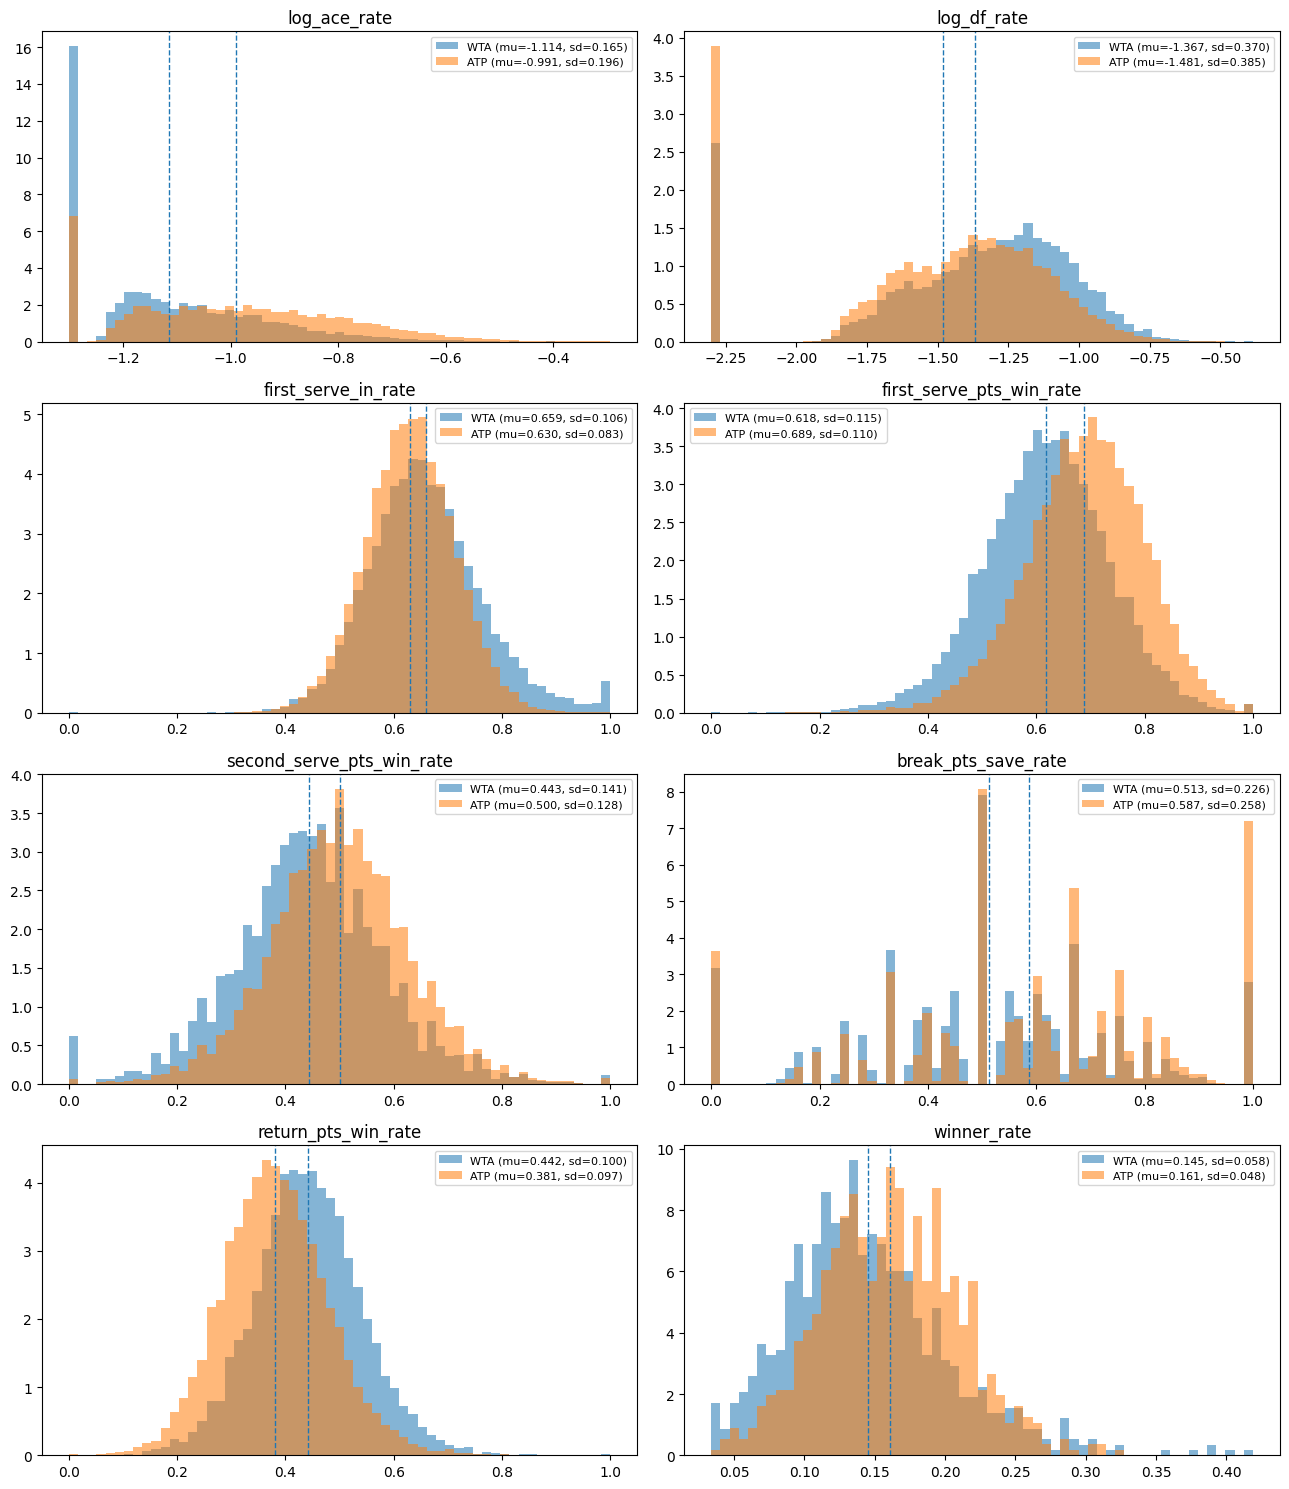

In [5]:
# Distribution of each rate, WTA against ATP on shared bins.
plot_cols = LOG_RATES + [c for c in RATES if c not in ('ace_rate', 'df_rate')]
fig, axes = plt.subplots(4, 2, figsize=(13, 15))

for ax, rate in zip(axes.ravel(), plot_cols):
    w, a = wta[rate].dropna(), atp[rate].dropna()
    bins = np.linspace(min(w.min(), a.min()), max(w.max(), a.max()), 60)
    ax.hist(w, bins=bins, alpha=0.55, label=f'WTA (mu={w.mean():.3f}, sd={w.std():.3f})', density=True)
    ax.hist(a, bins=bins, alpha=0.55, label=f'ATP (mu={a.mean():.3f}, sd={a.std():.3f})', density=True)
    ax.axvline(w.mean(), linestyle='--', linewidth=1)
    ax.axvline(a.mean(), linestyle='--', linewidth=1)
    ax.set_title(rate)
    ax.legend(fontsize=8)

fig.tight_layout()
plt.show()

## 2. Parameter inputs

`SRV`, `RET` and `SHOT` take the inputs that actually carry gradient to them in
`train_player_params.py`, derived by autograd rather than by reading the
formulas. Slopes are d(predictor)/d(parameter): the change in a predicted rate
per one rating unit. `opp_` columns are the same statistic taken from the
opponent's row of the same match.

`CONS` is redefined here. In the original model it was driven by
`unforced_error_rate` and `df_rate` -- both *level* statistics, which say how
often a player errs but nothing about whether they do it dependably. Consistency
is a claim about variance, so `CONS` also takes the **per-player standard
deviation across matches** of the five most reliable statistics.

In [6]:
def add_opponent_rates(df):
    """Attach each player's opponent's rates from the same match as opp_* columns."""
    carried = RATES + LOG_RATES
    right = df[['match_id', 'player'] + carried].rename(
        columns={'player': 'opponent', **{r: f'opp_{r}' for r in carried}})
    return df.merge(right, on=['match_id', 'opponent'], how='left')


wta = add_opponent_rates(wta)
atp = add_opponent_rates(atp)

# (column, slope) -- slope from d(predictor)/d(parameter) in train_player_params.py
SRV_INPUTS = [
    ('first_serve_in_rate',            +0.0170),
    ('break_pts_save_rate',            +0.0130),
    ('opp_return_pts_win_rate',        -0.0130),
    ('first_serve_pts_win_rate',       +0.0100),
    ('second_serve_pts_win_rate',      +0.0100),
    ('ace_rate',                       +0.0050),
]

RET_INPUTS = [
    ('opp_first_serve_pts_win_rate',   -0.0100),
    ('opp_second_serve_pts_win_rate',  -0.0100),
    ('opp_break_pts_save_rate',        -0.0096),
    ('return_pts_win_rate',            +0.0096),
]

SHOT_INPUTS = [
    ('first_serve_pts_win_rate',       +0.0200),
    ('opp_first_serve_pts_win_rate',   -0.0200),
    ('second_serve_pts_win_rate',      +0.0200),
    ('opp_second_serve_pts_win_rate',  -0.0200),
    ('break_pts_save_rate',            +0.0193),
    ('opp_break_pts_save_rate',        -0.0193),
    ('return_pts_win_rate',            +0.0191),
    ('opp_return_pts_win_rate',        -0.0191),
    ('winner_rate',                    +0.0100),
]

# CONS: two level terms, plus the dispersion of the five most reliable rates.
CONS_LEVEL_INPUTS = ['unforced_error_rate', 'df_rate']
STABLE = [
    'ace_rate',
    'df_rate',
    'first_serve_pts_win_rate',
    'return_pts_win_rate',
    'first_serve_in_rate',
]

for name, inputs in [('SRV', SRV_INPUTS), ('RET', RET_INPUTS), ('SHOT', SHOT_INPUTS)]:
    print(f'{name}: {len(inputs)} inputs')
print(f'CONS: {len(CONS_LEVEL_INPUTS)} level inputs + {len(STABLE)} dispersion inputs')

SRV: 6 inputs
RET: 4 inputs
SHOT: 9 inputs
CONS: 2 level inputs + 5 dispersion inputs


### Opponent strength

Every rate so far is unadjusted for who it was produced against: winning 45% of
return points off the world number one and off a qualifier count the same. The
correction adds

```
opponent_adjustment = log10(opponent ranking points) - 2
```

directly to each per-match contribution, in rating units. Log points rather than
rank because points are roughly log-spaced across the field, so the adjustment
degrades smoothly instead of treating rank 1 and rank 2 as far apart. The `-2`
centres it near zero for a player around 100 points.

**30 points is the floor for every player**, giving `log10(30) - 2 = -0.52` --
an opponent too low to be ranked is a mild penalty, not a neutral. 100 points is
still where the adjustment crosses zero. Range across the current lists:
**+2.11** for the ATP number one at 12,800 points, down to **-0.52** at the floor.

Rankings come from `rankings.json`, which is a **single current snapshot** -- the
feed carries no history, so a season of past matches is scored against today's
standings. A player who climbed or fell sharply over the window is mis-scored.

Opponents outside the top 500 (2.7% of ATP rows, 7.9% of WTA, mostly qualifying
and `wta_125`) take the floor, as do the few ranked players sitting below it --
they are genuinely at the bottom of the field rather than unmeasured.

In [7]:
ranking_rows = [
    {'opponent_id': entry['competitor']['id'],
     'opp_points': entry['points'],
     'opp_rank': entry['rank']}
    for ranking_list in client.rankings()
    for entry in ranking_list['competitor_rankings']
]
rankings = pd.DataFrame(ranking_rows)

# 30 points is the floor for everyone, ranked or not. It sits below the 100-point
# neutral, so log10(30) - 2 = -0.52: an opponent nobody can rank is now a small
# penalty rather than a neutral. That matters because the rankings feed carries
# only the top 500 per tour -- everyone below is indistinguishable, and treating
# them as merely average flattered every match played against them.
POINTS_FLOOR = 30

def add_opponent_strength(df):
    df = df.merge(rankings, on='opponent_id', how='left')
    df['opp_points'] = df['opp_points'].fillna(POINTS_FLOOR).clip(lower=POINTS_FLOOR)
    df['opp_adj'] = np.log10(df['opp_points']) - 2
    return df

wta = add_opponent_strength(wta)
atp = add_opponent_strength(atp)

for label, df in [('WTA', wta), ('ATP', atp)]:
    q, t = df['is_qualifying'], df['is_second_tier']
    print(f'{label}: qualifying {q.sum()} ({100 * q.mean():.0f}%), '
          f'second tier {t.sum()} ({100 * t.mean():.0f}%), '
          f'both {(q & t).sum()} -> penalised once, not twice | '
          f'rows carrying a penalty {int((df["penalty_z"] > 0).sum())} '
          f'({100 * (df["penalty_z"] > 0).mean():.0f}%)')
    ranked = df['opp_rank'].notna().mean()
    at_floor = (df['opp_points'] == POINTS_FLOOR).mean()
    print(f'{label}: {100 * ranked:.1f}% ranked opponents, {100 * at_floor:.1f}% at the '
          f'{POINTS_FLOOR}-point floor | opp_adj mean {df["opp_adj"].mean():+.3f}, '
          f'range {df["opp_adj"].min():+.2f} to {df["opp_adj"].max():+.2f}')

WTA: qualifying 3277 (29%), second tier 4571 (40%), both 949 -> penalised once, not twice | rows carrying a penalty 6899 (61%)
WTA: 92.1% ranked opponents, 7.9% at the 30-point floor | opp_adj mean +0.729, range -0.52 to +1.93
ATP: qualifying 10789 (35%), second tier 23352 (76%), both 8416 -> penalised once, not twice | rows carrying a penalty 25725 (83%)
ATP: 74.8% ranked opponents, 25.2% at the 30-point floor | opp_adj mean +0.266, range -0.52 to +2.11


### Per-player aggregation

A standard deviation over matches needs enough matches to mean anything, so the
dispersion inputs are only computed above `MIN_MATCHES_STD`.

The spread is also **corrected for sampling noise**. A rate measured over `n`
points carries binomial variance `p(1-p)/n` even from a player whose form never
moved, so the raw standard deviation reads noise as inconsistency -- and reads
it hardest for players whose matches are short. Across the WTA field the median
player had **42%** of their first-serve-in variance explained by sampling alone,
and measured dispersion correlated **-0.39** with average match length. So:

```
true_var = max(observed_var - mean(p(1-p)/n), 0)
```

floored at zero, since the estimate is noisy in both directions and a negative
variance has no reading.

In [8]:
# A standard deviation over a handful of matches is mostly sampling noise, so
# the dispersion inputs are only computed above MIN_MATCHES_STD. Players below
# it stay in the table -- they simply get the neutral 5.0 for those inputs
# rather than a dispersion nobody should believe.
DISPERSION_REPORT = {}
MIN_MATCHES_STD = 10
MIN_MATCHES_INCLUDE = 1

def design_effect(deviation_sq, sampling_unit):
    """How much the real sampling noise exceeds the independent-points model.

    Points inside a match are not independent -- games run in streaks, a player
    serving badly keeps serving badly -- so p(1-p)/n understates the true
    per-match noise. Regressing each match's squared deviation from its player's
    mean on its binomial prediction recovers the multiplier:

        (p_im - pbar_i)^2  ~  sigma^2_true  +  c * p_im(1-p_im)/n_im

    The slope c is the design effect; the intercept is the average true
    variance. c = 1 would mean points really are independent.
    """
    x = sampling_unit.to_numpy()
    y = deviation_sq.to_numpy()
    ok = np.isfinite(x) & np.isfinite(y)
    slope, _intercept = np.polyfit(x[ok], y[ok], 1)
    return max(float(slope), 1.0)


def true_dispersion(df, rate, min_matches=None, report=None):
    """Per-player TRUE variance of a rate: precision-weighted, noise-corrected,
    clipped at zero, then shrunk toward the tour mean.

    Four steps, each fixing something the plain standard deviation gets wrong:

    1. PRECISION WEIGHTING. A 150-point match pins the rate down far better
       than a 40-point one, so matches enter weighted by their denominator
       rather than equally.

    2. NOISE SUBTRACTION. Subtract the sampling variance the rate would show
       even from a player whose form never moved, scaled by the design effect
       because points within a match are correlated.

    3. CLIP AT ZERO, BEFORE SHRINKING. A true variance cannot be negative; a
       negative estimate is noise, not extraordinary steadiness. Clipping first
       stops noise outscoring genuine consistency -- shrinking first and
       clipping after rewards the most impossible estimates most.

    4. SHRINK TOWARD THE TOUR MEAN by w = (M-1)/(M-1+k). See `shrinkage_k`.

    Returns a variance, not a standard deviation, so the z-score downstream is
    taken in the same space the shrinkage happens in.
    """
    min_matches = MIN_MATCHES_STD if min_matches is None else min_matches
    denom = df[RATE_DENOM[rate]]
    usable = df[rate].notna() & denom.gt(0)
    frame = df[usable]
    p, n, player = frame[rate], denom[usable], frame['player']

    weight = n / n.mean()
    total_w = weight.groupby(player).sum()
    weighted_mean_p = (p * weight).groupby(player).sum() / total_w
    deviation_sq = (p - player.map(weighted_mean_p)) ** 2
    sampling_unit = p * (1 - p) / n

    c = design_effect(deviation_sq, sampling_unit)

    # weighted sample variance, unbiased for reliability weights
    sum_w2 = (weight ** 2).groupby(player).sum()
    observed = ((weight * deviation_sq).groupby(player).sum()
                / (total_w - sum_w2 / total_w))
    sampling = c * (weight * sampling_unit).groupby(player).sum() / total_w

    matches = frame.groupby('player').size()
    excess = (observed - sampling).clip(lower=0)          # step 3, before shrinking

    rated = matches >= min_matches
    mu = excess[rated].mean()
    k = shrinkage_k(observed[rated], excess[rated], matches[rated])

    shrink = (matches - 1) / ((matches - 1) + k)
    if report is not None:
        report[rate] = {'design_effect': round(c, 3), 'k': round(k, 1), 'mu': mu,
                        'w at M=12': round(11 / (11 + k), 3),
                        'w at M=40': round(39 / (39 + k), 3),
                        'w at M=75': round(74 / (74 + k), 3),
                        'pct_clipped': round(100 * ((observed - sampling)[rated] < 0).mean(), 1)}
    return shrink * excess + (1 - shrink) * mu


def shrinkage_k(observed, excess, matches):
    """The match count at which a player's own data earns half the estimate.

    Each player's variance estimate carries its own sampling error,
    Var(X_i) ~ 2 (S_i^2)^2 / (M_i - 1). Weighting own-data against the tour
    prior by relative precision gives w_i = tau^2 / (tau^2 + Var(X_i)), which
    rearranges to w_i = (M_i - 1) / (M_i - 1 + k) with

        k = 2 * mean(S^4) / tau^2

    where tau^2 is how much players genuinely differ, recovered by removing the
    estimator's own noise from the observed spread of estimates. So k is a
    signal-to-noise ratio expressed in matches: small k means players differ a
    lot relative to the noise and a short record is already informative; large k
    means the opposite. A player at M - 1 = k gets w = 0.5.
    """
    estimator_var = (2 * observed ** 2 / (matches - 1)).mean()
    tau2 = max(float(excess.var() - estimator_var), 1e-12)
    return 2 * float((observed ** 2).mean()) / tau2


def player_table(df, min_matches_include=MIN_MATCHES_INCLUDE, min_matches_std=MIN_MATCHES_STD):
    """One row per player: mean of every rate, plus the across-match standard
    deviation of the five stable rates -- the raw material for CONS.

    disp_* is NaN for players below min_matches_std; section 4 turns that NaN
    into a 5.0 contribution.
    """
    df = df.copy()
    df['total_pts'] = df['serve_pts'] + df['return_pts']
    grouped = df.groupby('player')
    out = pd.DataFrame({'matches': grouped.size()})
    for rate in RATES:
        out[f'mean_{rate}'] = grouped[rate].mean()
    for rate in STABLE:
        out[f'disp_{rate}'] = true_dispersion(df, rate, report=DISPERSION_REPORT)

    thin = out['matches'] < min_matches_std
    out.loc[thin, [f'disp_{r}' for r in STABLE]] = np.nan
    return out[out['matches'] >= min_matches_include]


wta_players = player_table(wta)
atp_players = player_table(atp)

for label, tbl in [('WTA', wta_players), ('ATP', atp_players)]:
    enough = (tbl['matches'] >= MIN_MATCHES_STD).sum()
    print(f'{label}: {len(tbl)} players rated; {enough} have >= {MIN_MATCHES_STD} matches '
          f'so carry real dispersion, {len(tbl) - enough} fall back to 5.0')

# unforced_error_rate only exists at slam main draws, so its per-player mean is
# absent for most of the pool -- worth seeing before CONS leans on it.
for label, tbl in [('WTA', wta_players), ('ATP', atp_players)]:
    have = tbl['mean_unforced_error_rate'].notna().sum()
    print(f'{label}: mean_unforced_error_rate present for {have}/{len(tbl)} players '
          f'({100 * have / len(tbl):.0f}%)')

WTA: 819 players rated; 321 have >= 10 matches so carry real dispersion, 498 fall back to 5.0
ATP: 1820 players rated; 761 have >= 10 matches so carry real dispersion, 1059 fall back to 5.0
WTA: mean_unforced_error_rate present for 183/819 players (22%)
ATP: mean_unforced_error_rate present for 178/1820 players (10%)


### Distribution of the per-player standard deviations

Mean and standard deviation, across players, of each per-player dispersion --
i.e. how much players vary in how much they vary. These are the centring and
scaling constants CONS needs to combine dispersions measured on different
scales.

In [9]:
def dispersion_summary(players, label):
    """Distribution of the per-player TRUE variance -- the centring and scaling
    constants the z-score uses."""
    cols = [f'disp_{r}' for r in STABLE]
    out = pd.DataFrame({
        'n_players':  players[cols].notna().sum(),   # only those above MIN_MATCHES_STD
        'mean_var':   players[cols].mean(),
        'sd_var':     players[cols].std(),
        'implied_sd': np.sqrt(players[cols].mean()),
        'min':        players[cols].min(),
        'max':        players[cols].max(),
    })
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out

dispersion = dispersion_summary(wta_players, 'WTA').join(dispersion_summary(atp_players, 'ATP'))
display(dispersion.round(6))

print('mean_var   : the typical player\'s true (noise-removed) variance')
print('sd_var     : how much that differs between players -- what the z-score divides by')
print('implied_sd : sqrt(mean_var), the same thing on the original rate scale')

print('\n=== estimated per rate, from the tour itself ===')
report = pd.DataFrame(DISPERSION_REPORT).T
display(report)
print('design_effect : ratio of real per-match noise to the independent-points model.')
print('                1.0 = points independent; above 1 = streaky, so more of the')
print('                observed spread is noise and more gets subtracted.')
print('k             : matches of own data worth as much as the tour prior. A player')
print('                with M-1 = k splits the estimate 50/50. Large k means players')
print('                barely differ relative to the noise, so short records are')
print('                pulled hard toward average.')
print('pct_clipped   : share of rated players whose raw estimate came out negative')
print('                and was clipped to zero before shrinking.')

WTA                                 \
                              n_players  mean_var    sd_var implied_sd   
disp_ace_rate                       321  0.000134  0.000050   0.011554   
disp_df_rate                        321  0.000167  0.000000   0.012930   
disp_first_serve_pts_win_rate       321  0.004431  0.000000   0.066569   
disp_return_pts_win_rate            321  0.000284  0.000000   0.016846   
disp_first_serve_in_rate            321  0.005214  0.001908   0.072210   

                                                        ATP            \
                                    min       max n_players  mean_var   
disp_ace_rate                  0.000094  0.000583       761  0.000146   
disp_df_rate                   0.000167  0.000167       761  0.000166   
disp_first_serve_pts_win_rate  0.004431  0.004431       761  0.003486   
disp_return_pts_win_rate       0.000284  0.000284       761  0.000272   
disp_first_serve_in_rate       0.001512  0.016153       761  0.001790   

                                                                        
                                 sd_var implied_sd       min       max  
disp_ace_rate                  0.000000   0.012070  0.000146  0.000146  
disp_df_rate                   0.000000   0.012873  0.000166  0.000166  
disp_first_serve_pts_win_rate  0.000000   0.059040  0.003486  0.003486  
disp_return_pts_win_rate       0.000000   0.016492  0.000272  0.000272  
disp_first_serve_in_rate       0.000064   0.042311  0.001642  0.002134

mean_var   : the typical player's true (noise-removed) variance
sd_var     : how much that differs between players -- what the z-score divides by
implied_sd : sqrt(mean_var), the same thing on the original rate scale

=== estimated per rate, from the tour itself ===


,design_effect,k,mu,w at M=12,w at M=40,w at M=75,pct_clipped
ace_rate,2.591,9418938.6,0.000146,0.000,0.000,0.000,76.2
df_rate,1.071,1366327.1,0.000166,0.000,0.000,0.000,28.3
first_serve_pts_win_rate,1.081,152725274.1,0.003486,0.000,0.000,0.000,5.3
return_pts_win_rate,2.799,111647455.0,0.000272,0.000,0.000,0.000,85.5
first_serve_in_rate,1.000,776.7,0.001789,0.014,0.048,0.087,13.5


design_effect : ratio of real per-match noise to the independent-points model.
                1.0 = points independent; above 1 = streaky, so more of the
                observed spread is noise and more gets subtracted.
k             : matches of own data worth as much as the tour prior. A player
                with M-1 = k splits the estimate 50/50. Large k means players
                barely differ relative to the noise, so short records are
                pulled hard toward average.
pct_clipped   : share of rated players whose raw estimate came out negative
                and was clipped to zero before shrinking.


## 3. Input weights

The original model weights each target 1.0 or 0.5 by hand. Those numbers are not
what reaches the parameter: the gradient is `weight x slope x error`, so a target
with a small slope moves its parameter feebly whatever weight it carries. In the
`srv` trace, `ace_rate` and `break_pts_save_rate` were both weighted 0.5, yet
`break_pts_save_rate` exerted **20x** more influence -- and it is the least
reliable statistic of the nine while `ace_rate` is the most.

Two weightings are computed here, per tour, from the data alone.

**`w_invvar` -- inverse sampling variance.** Each rate is a ratio whose
denominator is a point count, so one match's estimate has binomial standard
error `sqrt(p(1-p)/n)`. Weighting by `1/sigma^2` is ordinary inverse-variance
weighting: trust each measurement in proportion to its precision. This depends
on the binomial assumption but not on `train_player_params.py`.

**`w_reliability` -- split-half reliability.** Each player's matches are split
in half at random, the two half-means are correlated across players, and the
result is Spearman-Brown corrected. It answers "is this a stable property of the
player or match-to-match noise?" and assumes nothing at all -- no noise model,
no coefficients.

`WEIGHT_BASIS` selects which one feeds the parameters. They agree closely on the
serve rates; where they differ, `w_reliability` is the safer default because it
makes no distributional assumption. Set it to `'invvar'` for the other.

In [10]:
def compute_weights(df, min_matches=MIN_MATCHES_STD, repeats=20, seed=0):
    """Per-rate inverse-variance and split-half-reliability weights, from data."""
    rng = np.random.default_rng(seed)
    df = df.copy()
    df['total_pts'] = df['serve_pts'] + df['return_pts']
    rows = {}
    for rate, denom in RATE_DENOM.items():
        sub = df[['player', rate, denom]].dropna()
        sub = sub[sub[denom] > 0]
        p, n = sub[rate].mean(), sub[denom].median()
        noise = np.sqrt(p * (1 - p) / n)

        counts = sub.groupby('player')[rate].size()
        keep = counts[counts >= min_matches].index
        half = sub[sub['player'].isin(keep)]
        correlations = []
        for _ in range(repeats):
            marked = half.assign(half=rng.integers(0, 2, len(half)))
            pivot = marked.groupby(['player', 'half'])[rate].mean().unstack().dropna()
            if len(pivot) > 5:
                correlations.append(pivot[0].corr(pivot[1]))
        r = float(np.mean(correlations))
        rows[rate] = {'n': len(sub), 'median_denom': n, 'noise_sd': noise,
                      'split_half_r': r, 'reliability': 2 * r / (1 + r)}

    out = pd.DataFrame(rows).T
    out['w_invvar'] = (1 / out['noise_sd'] ** 2) / (1 / out['noise_sd'] ** 2).max()
    out['w_reliability'] = out['reliability'] / out['reliability'].max()
    return out


def dispersion_reliability(df, rate, min_matches=20, repeats=8, seed=0):
    """Split-half reliability of a player's match-to-match VARIANCE.

    The same split-half question as compute_weights, asked one level up: split a
    player's matches in two, measure the spread within each half, and see
    whether the two halves agree across players. A rate can be highly
    repeatable while how much it *swings* is not -- so this has to be measured
    on the dispersion itself, not inherited from the rate underneath.
    """
    rng = np.random.default_rng(seed)
    sub = df[['player', rate]].dropna()
    sub = sub[sub.groupby('player')[rate].transform('size') >= min_matches]
    if sub['player'].nunique() < 15:
        return np.nan
    correlations = []
    for _ in range(repeats):
        marked = sub.assign(half=rng.integers(0, 2, len(sub)))
        pivot = marked.groupby(['player', 'half'])[rate].var().unstack().dropna()
        if len(pivot) > 10:
            correlations.append(pivot[0].corr(pivot[1]))
    r = float(np.mean(correlations))
    return 2 * r / (1 + r)


def dispersion_weights(df):
    """Weight for each disp_* input: its own reliability, normalised."""
    raw = pd.Series({rate: dispersion_reliability(df, rate) for rate in STABLE})
    return raw / raw.max()


wta_weights = compute_weights(wta)
atp_weights = compute_weights(atp)
wta_disp_weights = dispersion_weights(wta)
atp_disp_weights = dispersion_weights(atp)

WEIGHT_BASIS = 'reliability'          # or 'invvar'
WEIGHT_COL = f'w_{WEIGHT_BASIS}'

print(f'weighting on {WEIGHT_COL}\n')
display(pd.concat({'WTA': wta_weights, 'ATP': atp_weights}, axis=1).round(4))

print('\n=== dispersion inputs are weighted by the reliability of the DISPERSION ===')
comparison = pd.DataFrame({
    'WTA reliability of rate':       wta_weights.loc[STABLE, 'reliability'],
    'WTA reliability of dispersion': [dispersion_reliability(wta, r) for r in STABLE],
    'ATP reliability of rate':       atp_weights.loc[STABLE, 'reliability'],
    'ATP reliability of dispersion': [dispersion_reliability(atp, r) for r in STABLE],
    'WTA disp weight':               wta_disp_weights,
    'ATP disp weight':               atp_disp_weights,
})
display(comparison.round(3))
print('Weighting a dispersion by its rate\'s reliability over-credits it: how often a')
print('player aces is far more repeatable than how much their ace rate swings.')

weighting on w_reliability



WTA                                     \
                                 n median_denom noise_sd split_half_r   
ace_rate                   11354.0         65.0   0.0222       0.8219   
df_rate                    11354.0         65.0   0.0274       0.7513   
first_serve_in_rate        11353.0         65.0   0.0588       0.7155   
first_serve_pts_win_rate   11352.0         43.0   0.0741       0.5785   
second_serve_pts_win_rate  11316.0         23.0   0.1036       0.2895   
break_pts_save_rate        11094.0          8.0   0.1767       0.0922   
return_pts_win_rate        11354.0         65.0   0.0616       0.2963   
winner_rate                  890.0        132.0   0.0307       0.4322   
unforced_error_rate          889.0        132.0   0.0341       0.5203   

                                                                  ATP  \
                          reliability w_invvar w_reliability        n   
ace_rate                       0.9023   1.0000        1.0000  30694.0   
df_rate                        0.8580   0.6575        0.9510  30694.0   
first_serve_in_rate            0.8342   0.1428        0.9246  30694.0   
first_serve_pts_win_rate       0.7329   0.0899        0.8123  30693.0   
second_serve_pts_win_rate      0.4490   0.0460        0.4977  30698.0   
break_pts_save_rate            0.1689   0.0158        0.1872  29203.0   
return_pts_win_rate            0.4572   0.1302        0.5067  30694.0   
winner_rate                    0.6036   0.5243        0.6689    862.0   
unforced_error_rate            0.6844   0.4240        0.7586    862.0   

                                                                          \
                          median_denom noise_sd split_half_r reliability   
ace_rate                          68.0   0.0296       0.8658      0.9281   
df_rate                           68.0   0.0237       0.7522      0.8585   
first_serve_in_rate               68.0   0.0585       0.7656      0.8673   
first_serve_pts_win_rate          43.0   0.0706       0.6464      0.7852   
second_serve_pts_win_rate         25.0   0.1000       0.3728      0.5431   
break_pts_save_rate                6.0   0.2010       0.1491      0.2594   
return_pts_win_rate               68.0   0.0589       0.4947      0.6620   
winner_rate                      220.0   0.0248       0.4754      0.6444   
unforced_error_rate              220.0   0.0243       0.2778      0.4348   

                                                  
                          w_invvar w_reliability  
ace_rate                    0.6456        1.0000  
df_rate                     1.0000        0.9251  
first_serve_in_rate         0.1645        0.9345  
first_serve_pts_win_rate    0.1131        0.8461  
second_serve_pts_win_rate   0.0564        0.5852  
break_pts_save_rate         0.0140        0.2795  
return_pts_win_rate         0.1625        0.7133  
winner_rate                 0.9175        0.6944  
unforced_error_rate         0.9545        0.4685


=== dispersion inputs are weighted by the reliability of the DISPERSION ===


,WTA reliability of rate,WTA reliability of dispersion,ATP reliability of rate,ATP reliability of dispersion,WTA disp weight,ATP disp weight
ace_rate,0.902,0.669,0.928,0.689,1.000,1.000
df_rate,0.858,0.625,0.859,0.595,0.936,0.865
first_serve_pts_win_rate,0.733,0.081,0.785,0.193,0.121,0.281
return_pts_win_rate,0.457,0.200,0.662,0.218,0.300,0.317
first_serve_in_rate,0.834,0.163,0.867,0.223,0.243,0.324


Weighting a dispersion by its rate's reliability over-credits it: how often a
player aces is far more repeatable than how much their ace rate swings.


### Documented input map

One row per contributing statistic. `role` says whose row it is read from,
`slope` is d(predictor)/d(parameter) from `train_player_params.py`, `sign` is the
direction the statistic pushes the rating, and `weight` is the data-derived
weight replacing the hand-set 1.0 / 0.5. `effective` is the weight normalised
within each parameter, so it reads as a share of that rating.

In [11]:
# statistic -> which rate's weight applies (opp_* reuses the same statistic)
def base_rate(column):
    return column[4:] if column.startswith('opp_') else column

PARAM_INPUTS = {
    'SRV':  SRV_INPUTS,
    'RET':  RET_INPUTS,
    'SHOT': SHOT_INPUTS,
    # CONS: level terms carry their own slope from the model; the dispersion
    # terms take the reliability of the dispersion itself (see
    # dispersion_weights), not of the rate underneath.
    'CONS': [('unforced_error_rate', -0.0100), ('df_rate', -0.0030)]
            + [(f'disp_{r}', -1.0) for r in STABLE],
}

def input_weight(column, weights, disp_weights):
    """A disp_* input is trusted according to how repeatable that dispersion is;
    every other input according to how repeatable its rate is."""
    stat = base_rate(column)
    if stat.startswith('disp_'):
        return float(disp_weights[stat.removeprefix('disp_')])
    return float(weights.loc[stat, WEIGHT_COL])


def input_map(weights, disp_weights, label):
    rows = []
    for param, inputs in PARAM_INPUTS.items():
        for column, slope in inputs:
            stat = base_rate(column).removeprefix('disp_')
            rows.append({
                'parameter': param,
                'statistic': column,
                'role': 'opponent' if column.startswith('opp_') else 'own',
                'kind': 'dispersion' if column.startswith('disp_') else 'level',
                'slope': slope,
                'sign': '+' if slope > 0 else '-',
                'weight': input_weight(column, weights, disp_weights),
            })
    table = pd.DataFrame(rows)
    table['effective'] = table.groupby('parameter')['weight'].transform(lambda w: w / w.sum())
    table.insert(0, 'tour', label)
    return table

input_maps = pd.concat([input_map(wta_weights, wta_disp_weights, 'WTA'),
                        input_map(atp_weights, atp_disp_weights, 'ATP')],
                       ignore_index=True)

for param in PARAM_INPUTS:
    print(f'\n=== {param} ===')
    view = input_maps[input_maps.parameter == param].pivot_table(
        index=['statistic', 'role', 'kind', 'sign'], columns='tour',
        values=['weight', 'effective'])
    display(view.round(4))


=== SRV ===


effective          weight  \
tour                                                ATP     WTA     ATP   
statistic                 role     kind  sign                             
ace_rate                  own      level +       0.2294  0.2546  1.0000   
break_pts_save_rate       own      level +       0.0641  0.0477  0.2795   
first_serve_in_rate       own      level +       0.2144  0.2353  0.9345   
first_serve_pts_win_rate  own      level +       0.1941  0.2068  0.8461   
opp_return_pts_win_rate   opponent level -       0.1636  0.1290  0.7133   
second_serve_pts_win_rate own      level +       0.1343  0.1267  0.5852   

                                                       
tour                                              WTA  
statistic                 role     kind  sign          
ace_rate                  own      level +     1.0000  
break_pts_save_rate       own      level +     0.1872  
first_serve_in_rate       own      level +     0.9246  
first_serve_pts_win_rate  own      level +     0.8123  
opp_return_pts_win_rate   opponent level -     0.5067  
second_serve_pts_win_rate own      level +     0.4977


=== RET ===


effective          weight  \
tour                                                    ATP     WTA     ATP   
statistic                     role     kind  sign                             
opp_break_pts_save_rate       opponent level -       0.1153  0.0934  0.2795   
opp_first_serve_pts_win_rate  opponent level -       0.3490  0.4054  0.8461   
opp_second_serve_pts_win_rate opponent level -       0.2414  0.2483  0.5852   
return_pts_win_rate           own      level +       0.2942  0.2529  0.7133   

                                                           
tour                                                  WTA  
statistic                     role     kind  sign          
opp_break_pts_save_rate       opponent level -     0.1872  
opp_first_serve_pts_win_rate  opponent level -     0.8123  
opp_second_serve_pts_win_rate opponent level -     0.4977  
return_pts_win_rate           own      level +     0.5067


=== SHOT ===


effective          weight  \
tour                                                    ATP     WTA     ATP   
statistic                     role     kind  sign                             
break_pts_save_rate           own      level +       0.0504  0.0400  0.2795   
first_serve_pts_win_rate      own      level +       0.1526  0.1737  0.8461   
opp_break_pts_save_rate       opponent level -       0.0504  0.0400  0.2795   
opp_first_serve_pts_win_rate  opponent level -       0.1526  0.1737  0.8461   
opp_return_pts_win_rate       opponent level -       0.1287  0.1083  0.7133   
opp_second_serve_pts_win_rate opponent level -       0.1056  0.1064  0.5852   
return_pts_win_rate           own      level +       0.1287  0.1083  0.7133   
second_serve_pts_win_rate     own      level +       0.1056  0.1064  0.5852   
winner_rate                   own      level +       0.1253  0.1430  0.6944   

                                                           
tour                                                  WTA  
statistic                     role     kind  sign          
break_pts_save_rate           own      level +     0.1872  
first_serve_pts_win_rate      own      level +     0.8123  
opp_break_pts_save_rate       opponent level -     0.1872  
opp_first_serve_pts_win_rate  opponent level -     0.8123  
opp_return_pts_win_rate       opponent level -     0.5067  
opp_second_serve_pts_win_rate opponent level -     0.4977  
return_pts_win_rate           own      level +     0.5067  
second_serve_pts_win_rate     own      level +     0.4977  
winner_rate                   own      level +     0.6689


=== CONS ===


effective          weight  \
tour                                                     ATP     WTA     ATP   
statistic                     role kind       sign                             
df_rate                       own  level      -       0.2213  0.2207  0.9251   
disp_ace_rate                 own  dispersion -       0.2392  0.2321  1.0000   
disp_df_rate                  own  dispersion -       0.2068  0.2171  0.8647   
disp_first_serve_in_rate      own  dispersion -       0.0775  0.0565  0.3241   
disp_first_serve_pts_win_rate own  dispersion -       0.0672  0.0281  0.2809   
disp_return_pts_win_rate      own  dispersion -       0.0759  0.0695  0.3172   
unforced_error_rate           own  level      -       0.1121  0.1760  0.4685   

                                                            
tour                                                   WTA  
statistic                     role kind       sign          
df_rate                       own  level      -     0.9510  
disp_ace_rate                 own  dispersion -     1.0000  
disp_df_rate                  own  dispersion -     0.9356  
disp_first_serve_in_rate      own  dispersion -     0.2433  
disp_first_serve_pts_win_rate own  dispersion -     0.1212  
disp_return_pts_win_rate      own  dispersion -     0.2995  
unforced_error_rate           own  level      -     0.7586

In [12]:
# What the reweighting changes, against the original hand-set numbers.
OLD_WEIGHTS = {
    'ace_rate': 0.5, 'df_rate': 1.0, 'first_serve_in_rate': 1.0,
    'first_serve_pts_win_rate': 0.5, 'second_serve_pts_win_rate': 1.0,
    'break_pts_save_rate': 0.5, 'return_pts_win_rate': 1.0,
    'winner_rate': 1.0, 'unforced_error_rate': 1.0,
}
comparison = pd.DataFrame({
    'old (hand-set)': pd.Series(OLD_WEIGHTS),
    'WTA w_reliability': wta_weights['w_reliability'],
    'ATP w_reliability': atp_weights['w_reliability'],
    'WTA w_invvar': wta_weights['w_invvar'],
    'ATP w_invvar': atp_weights['w_invvar'],
})
comparison['reliability / old'] = comparison['ATP w_reliability'] / comparison['old (hand-set)']
display(comparison.sort_values('ATP w_reliability', ascending=False).round(4))

,old (hand-set),WTA w_reliability,ATP w_reliability,WTA w_invvar,ATP w_invvar,reliability / old
ace_rate,0.5,1.0000,1.0000,1.0000,0.6456,2.0000
first_serve_in_rate,1.0,0.9246,0.9345,0.1428,0.1645,0.9345
df_rate,1.0,0.9510,0.9251,0.6575,1.0000,0.9251
first_serve_pts_win_rate,0.5,0.8123,0.8461,0.0899,0.1131,1.6921
return_pts_win_rate,1.0,0.5067,0.7133,0.1302,0.1625,0.7133
winner_rate,1.0,0.6689,0.6944,0.5243,0.9175,0.6944
second_serve_pts_win_rate,1.0,0.4977,0.5852,0.0460,0.0564,0.5852
unforced_error_rate,1.0,0.7586,0.4685,0.4240,0.9545,0.4685
break_pts_save_rate,0.5,0.1872,0.2795,0.0158,0.0140,0.5591


## 4. Statistic to rating contribution

Each contributing statistic becomes a rating on the model's own scale, where
5.0 is the tour-average player:

```
z = (statistic - mean) / std          # log-transformed first where a log column exists
contribution = 5 + 2z   if the statistic is good for that rating  (slope > 0)
contribution = 5 - 2z   if it is bad for that rating              (slope < 0)
```

The `2z` scaling puts one standard deviation at two rating points, so a
tour-average player sits at 5.0 and a 2.5-sigma outlier at 10.0 or 0.0.

Which mean and std apply depends on the kind of input:

- **level** statistics use the match-level mean and std from section 1, per tour;
- **dispersion** statistics (`std_*`) use the across-player mean and std of that
  per-player dispersion, from section 2.

Sign follows the slope, so a statistic that is bad for a rating inverts. Higher
`opp_return_pts_win_rate` means the opponent returned well against this player,
so it lowers `SRV`; higher `df_rate` and higher dispersion both lower `CONS`.

In [13]:
LOG_OF = {'ace_rate': 'log_ace_rate', 'df_rate': 'log_df_rate'}

def z_source(column):
    """Column actually z-scored -- the log version wherever one exists."""
    if column.startswith('opp_'):
        inner = column[4:]
        return 'opp_' + LOG_OF.get(inner, inner)
    return LOG_OF.get(column, column)


def build_norms(matches, players):
    """(mean, std) for every column that can be z-scored, on this tour alone."""
    norms = {}
    for rate in RATES + LOG_RATES:
        norms[rate] = (matches[rate].mean(), matches[rate].std())
        opp = f'opp_{rate}'
        if opp in matches:
            norms[opp] = norms[rate]          # same population, other side of the net
    for rate in STABLE:                        # dispersion: across players, not matches
        column = f'disp_{rate}'
        norms[column] = (players[column].mean(), players[column].std())
    return norms


def contribution(values, mean, std, slope):
    """Statistic -> rating on the 5-centred scale, inverted when slope < 0."""
    z = (values - mean) / std
    return 5 + 2 * z if slope > 0 else 5 - 2 * z


wta_norms = build_norms(wta, wta_players)
atp_norms = build_norms(atp, atp_players)

# worked example, so the arithmetic is visible rather than implied
mean, std = atp_norms['log_ace_rate']
for label, raw_ace in [('tour average', atp['ace_rate'].mean()), ('big server 0.20', 0.20), ('no aces 0.00', 0.00)]:
    lg = np.log10(raw_ace + ACE_OFFSET)
    print(f'  ATP {label:<18} ace_rate={raw_ace:.4f} -> log {lg:+.4f} '
          f'-> z {(lg-mean)/std:+.3f} -> SRV contribution {contribution(lg, mean, std, +1):.2f}')

  ATP tour average       ace_rate=0.0634 -> log -0.9454 -> z +0.232 -> SRV contribution 5.46
  ATP big server 0.20    ace_rate=0.2000 -> log -0.6021 -> z +1.981 -> SRV contribution 8.96
  ATP no aces 0.00       ace_rate=0.0000 -> log -1.3010 -> z -1.581 -> SRV contribution 1.84


In [14]:
OPP_STRENGTH_SCALE = 1.0   # rating points per unit of log10(opponent points)

# SHOT shares 8 of its 9 inputs with SRV and RET, and comes out correlated 0.93
# with SRV / 0.99 with OVR -- it restates the overall rating rather than
# measuring shot quality. Winning first- and second-serve points is the biggest
# part of that overlap, and a big server wins those off the serve itself, not
# off the rally. So inside SHOT only, those two inputs are debuffed by the
# player's ace rate for that match: serve away the point and SHOT gets no
# credit; win it from the back of the court and the credit stands.
#
# ace_rate is the proxy because it is the purest serve signal available
# (reliability 0.93), it is not itself a SHOT input, and being per-match it
# tracks how the serve actually went rather than a static rating.
# Symmetric, because the same confound runs both ways. Your own serve-point
# wins are inflated by your serve, so they are debited by your ace rate. Your
# opponent's serve-point wins count against your SHOT, but a huge server on the
# other side is no evidence your shot quality is poor -- so those are credited
# back by THEIR ace rate.
SHOT_SERVE_DEBUFF = 0.5      # z-scores of ace advantage netted out
SHOT_SERVE_INPUTS = {'first_serve_pts_win_rate', 'second_serve_pts_win_rate'}
SHOT_OPP_SERVE_INPUTS = {'opp_first_serve_pts_win_rate', 'opp_second_serve_pts_win_rate'}


def rating_contributions(matches, players, norms, weights):
    """Per-player rating contribution from every contributing statistic.

    Dispersion (std_*) inputs are left unadjusted: they summarise a whole
    season rather than one match, so there is no single opponent to credit.
    """
    frames = {}
    for param, inputs in PARAM_INPUTS.items():
        columns = {}
        for column, slope in inputs:
            if column.startswith('disp_'):          # already one value per player
                mean, std = norms[column]
                # slope < 0, so contribution = 5 - 2z: a player whose match-to-match
                # spread is below average gets z < 0 and lands above 5.0. Less
                # variance, higher CONS.
                value = contribution(players[column], mean, std, slope)
                # Below MIN_MATCHES_STD the dispersion is unmeasured, not zero --
                # fall back to the neutral 5.0 so it neither helps nor hurts.
                columns[column] = value.fillna(5.0)
            else:                                   # per match -> average per player
                source = z_source(column)
                mean, std = norms[source]
                per_match = contribution(matches[source], mean, std, slope)
                # Credit the level of opposition. Added after the sign is applied,
                # so a strong opponent always flatters the contribution -- a high
                # unforced-error rate against the world number one is excused, not
                # punished, which folding it into z before the flip would get wrong.
                per_match = (per_match
                             + OPP_STRENGTH_SCALE * matches['opp_adj']
                             - Z_IN_RATING_POINTS * matches['penalty_z'])
                if param == 'SHOT' and column in SHOT_SERVE_INPUTS | SHOT_OPP_SERVE_INPUTS:
                    ace_mean, ace_sd = norms['log_ace_rate']
                    own_side = column in SHOT_SERVE_INPUTS
                    source = 'log_ace_rate' if own_side else 'opp_log_ace_rate'
                    z_ace = (matches[source] - ace_mean) / ace_sd
                    # own side: debit. opponent side (negative slope): credit back.
                    direction = -1.0 if own_side else +1.0
                    per_match = (per_match
                                 + direction * SHOT_SERVE_DEBUFF * Z_IN_RATING_POINTS * z_ace)
                columns[column] = (per_match.groupby(matches['player']).mean()
                                   .reindex(players.index))
        frames[param] = pd.DataFrame(columns)
    return frames


def combine(frames, weights, disp_weights):
    """Weighted mean of the contributions, renormalising over what is present.

    winner_rate and unforced_error_rate exist only at slam main draws, so for
    most players those columns are NaN -- the weight is redistributed across the
    inputs that do exist rather than dragging the rating toward nothing.
    """
    ratings = {}
    for param, frame in frames.items():
        w = pd.Series({c: input_weight(c, weights, disp_weights) for c in frame.columns})
        present = frame.notna()
        denominator = present.mul(w, axis=1).sum(axis=1)
        numerator = frame.mul(w, axis=1).sum(axis=1, skipna=True)
        ratings[param] = numerator / denominator.replace(0, np.nan)
    out = pd.DataFrame(ratings)

    # CONS splits into the two different claims it is making, using the same
    # weights so the parts still average to the whole:
    #
    #   CONS_ERR  the level inputs -- how often the player misses. A rate.
    #   CONS_VOL  the dispersion inputs -- how much their rates swing between
    #             matches. A variance. Higher still means better, i.e. steadier.
    #
    # The simulator needs these apart: CONS_ERR belongs in the per-shot error
    # probability, CONS_VOL in match-to-match form, and pushing a variance into
    # a rate slot would model neither.
    cons = frames['CONS']
    for label, columns in (('CONS_ERR', [c for c in cons.columns if not c.startswith('disp_')]),
                           ('CONS_VOL', [c for c in cons.columns if c.startswith('disp_')])):
        w = pd.Series({c: input_weight(c, weights, disp_weights) for c in columns})
        part = cons[columns]
        # Present-weight per player, not the constant: unforced_error_rate is
        # absent for ~90% of players, so each half carries a different weight
        # for each player and the two only recombine into CONS using these.
        weight_present = part.notna().mul(w, axis=1).sum(axis=1)
        out[label] = (part.mul(w, axis=1).sum(axis=1, skipna=True)
                      / weight_present.replace(0, np.nan))
        out[f'w_{label}'] = weight_present

    out['n_inputs_used'] = sum(f.notna().sum(axis=1) for f in frames.values())
    return out


wta_contrib = rating_contributions(wta, wta_players, wta_norms, wta_weights)
atp_contrib = rating_contributions(atp, atp_players, atp_norms, atp_weights)

wta_ratings = combine(wta_contrib, wta_weights, wta_disp_weights).join(wta_players[['matches']])
atp_ratings = combine(atp_contrib, atp_weights, atp_disp_weights).join(atp_players[['matches']])

# CONS must still be the weighted mean of its two halves.
for label, ratings, weights, disp_weights in [('WTA', wta_ratings, wta_weights, wta_disp_weights),
                                              ('ATP', atp_ratings, atp_weights, atp_disp_weights)]:
    w_err, w_vol = ratings['w_CONS_ERR'], ratings['w_CONS_VOL']
    rebuilt = (w_err * ratings['CONS_ERR'].fillna(0)
               + w_vol * ratings['CONS_VOL'].fillna(0)) / (w_err + w_vol)
    gap = (rebuilt - ratings['CONS']).abs().max()
    share = (w_vol / (w_err + w_vol))
    print(f'{label}: CONS = (w_err x CONS_ERR + w_vol x CONS_VOL) / (w_err + w_vol), per player'
          f'   -> CONS_VOL carries {100 * share.mean():.0f}% on average '
          f'({100 * share.min():.0f}-{100 * share.max():.0f}%)'
          f'   | max reconstruction error {gap:.2e}')
    assert gap < 1e-9, 'CONS is no longer the weighted mean of its parts'

print()
print('ATP -- contributions to SRV for the top 5 by combined SRV rating:')
top = atp_ratings.sort_values('SRV', ascending=False).head(5).index
display(atp_contrib['SRV'].loc[top].round(2))

WTA: CONS = (w_err x CONS_ERR + w_vol x CONS_VOL) / (w_err + w_vol), per player   -> CONS_VOL carries 70% on average (60-100%)   | max reconstruction error 3.55e-15
ATP: CONS = (w_err x CONS_ERR + w_vol x CONS_VOL) / (w_err + w_vol), per player   -> CONS_VOL carries 74% on average (67-75%)   | max reconstruction error 2.66e-15

ATP -- contributions to SRV for the top 5 by combined SRV rating:


,first_serve_in_rate,break_pts_save_rate,opp_return_pts_win_rate,first_serve_pts_win_rate,second_serve_pts_win_rate,ace_rate
player,,,,,,
Jannik Sinner,6.75,7.45,8.70,8.49,7.77,8.23
Reilly Opelka,7.37,6.85,7.74,7.46,6.53,10.02
Taylor Fritz,6.97,7.08,7.89,7.98,6.61,9.40
Alexander Zverev,8.64,6.13,8.02,7.44,7.36,7.90
Felix Auger-Aliassime,7.34,6.99,7.86,7.89,6.66,8.66


In [15]:
PARAMS = ['SRV', 'RET', 'SHOT', 'CONS']

print('=== distribution of the resulting ratings ===')
display(pd.concat({'WTA': wta_ratings[PARAMS].describe().T,
                   'ATP': atp_ratings[PARAMS].describe().T}, axis=0).round(3))

print('\nUnscaled, before opponent adjustment is folded in and before section 5.')
print('The spread is well under the 2.0 the 2z scaling implies: z is taken against')
print('the match-level std, then averaged over a player\'s matches, and that average')
print('shrinks the spread by roughly sqrt(reliability). Section 5 sets the range')
print('explicitly with a min-max map, so the damping no longer matters downstream.')

display(atp_ratings.sort_values('SRV', ascending=False)
        .head(15)[PARAMS + ['matches']].round(2))
display(wta_ratings.sort_values('RET', ascending=False)
        .head(15)[PARAMS + ['matches']].round(2))

=== distribution of the resulting ratings ===


count   mean    std    min    25%    50%    75%     max
WTA SRV    818.0  3.277  1.514 -1.526  2.363  3.214  4.047   7.682
    RET    819.0  3.283  1.619 -2.421  2.441  3.455  4.259  12.582
    SHOT   819.0  3.288  1.533 -2.244  2.471  3.250  4.148  12.021
    CONS   819.0  4.646  0.727  0.687  4.195  4.574  5.017   7.000
ATP SRV   1820.0  2.342  1.585 -3.398  1.432  2.395  3.150   7.929
    RET   1820.0  2.516  1.463 -3.158  1.696  2.701  3.413   7.115
    SHOT  1820.0  2.441  1.407 -2.627  1.621  2.555  3.206   7.415
    CONS  1820.0  4.397  0.721  0.401  3.997  4.314  4.726   7.095


Unscaled, before opponent adjustment is folded in and before section 5.
The spread is well under the 2.0 the 2z scaling implies: z is taken against
the match-level std, then averaged over a player's matches, and that average
shrinks the spread by roughly sqrt(reliability). Section 5 sets the range
explicitly with a min-max map, so the damping no longer matters downstream.


,SRV,RET,SHOT,CONS,matches
player,,,,,
Jannik Sinner,7.93,7.11,7.41,6.39,75
Reilly Opelka,7.91,3.79,5.44,3.05,25
Taylor Fritz,7.83,5.40,6.36,6.51,58
Alexander Zverev,7.80,6.00,6.64,5.97,76
Felix Auger-Aliassime,7.72,5.74,6.42,6.51,72
Ben Shelton,7.69,5.17,6.46,6.40,57
Nick Kyrgios,7.45,3.63,5.02,5.51,4
Alexander Bublik,7.36,5.29,6.18,3.74,59
Brandon Nakashima,7.32,5.64,6.17,6.77,61


,SRV,RET,SHOT,CONS,matches
player,,,,,
Ekaterina Perelygina,NaN,12.58,12.02,5.00,1
Iga Swiatek,6.88,7.25,7.17,6.33,55
Coco Gauff,6.65,6.91,6.49,4.75,62
Mirra Andreeva,6.78,6.76,6.65,5.91,54
Marta Kostyuk,6.96,6.74,6.75,5.51,43
Jessica Pegula,7.22,6.68,6.97,6.82,70
Elina Svitolina,6.70,6.66,6.65,6.32,50
Amanda Anisimova,7.26,6.65,6.93,5.32,45
Belinda Bencic,6.65,6.42,6.73,6.51,42


## 5. Thin-data shrinkage, ejection, and scaling

Three steps, in this order, because each depends on the one before.

**Eject.** A player with no usable contribution at all for some rating cannot be
rated on it, and leaving them in would let a `NaN` or a fluke set the scale for
everyone. They are dropped before anything is measured.

**Shrink.** `p` is computed **per rating, against that rating's own inputs**. SHOT
draws on 9 contributing statistics, so a player missing 8 of them has `p = 8/9`
for SHOT -- and SRV, with its own 6 inputs, is judged separately. The rating is then pulled toward 2.0 by a weight `x`:

```
x = max(2p - 1,  depth(matches))        clipped to [0, 1]
r -> x * anchor + (1 - x) * r

depth = 1 - matches / 10        for SRV, RET, SHOT   (0 from ten matches on)
depth = (10/3) / (10/3 + m)     for CONS             (0.25 at ten, never 0)
```

CONS uses a different curve and a different anchor because it needs more
evidence than the other three and had two artefacts of its own: a 4x jump in
mean across the ten-match line, and 123 players stranded below 0.1 when the
anchor was 0. Anchors are 2.0 for SRV/RET/SHOT and 0.5 for CONS.

`x` takes the worse of two independent thinness measures. `2p - 1` counts inputs
that do not exist; `1 - matches / 10` counts inputs that exist but rest on too
few matches. The second term is doing real work: one match already yields all
six SRV statistics, so `p` alone scores a single-match player as fully evidenced
on SRV and leaves them at the top of the leaderboard.

Clipping at 0 matters -- for a well-evidenced player both terms are negative, and
a negative `x` would push the rating away from the anchor and inflate it. Clipped,
the formula gates itself: `x = 0` leaves the rating exactly as it was.

The anchor is 2 rather than the 5.0 baseline, so a rating losing its evidence
reads as unproven rather than average -- **except CONS, which anchors at 0**.
CONS is built from dispersions, and an anchor of 2 put a floor under thin
players that measured players never got: every sub-10-match player outscored the
three most erratic players in the tour. Anchoring CONS at 0 removes the floor.

A dispersion input counts as missing below `MIN_MATCHES_STD`: the 5.0 in that
cell is a placeholder for a measurement nobody could take, not evidence that the
player is average.

**Scale.** Each rating is then mapped linearly onto 0-10 by its own min and max,
per tour:

```
scaled = (r - min) / (max - min) * 10
```

Scaling last keeps the shrunk players inside the range being fitted rather than
stretching it, and the result is bounded at both ends.

In [16]:
# Unproven players are pulled toward the bottom of each rating. CONS anchors at
# 0 rather than 2: its inputs are dispersions, and anchoring at 2 put a floor
# under thin players that measured-but-erratic players never got -- every
# sub-10-match player outscored the genuinely most erratic ones.
SHRINK_ANCHOR = {'SRV': 2.0, 'RET': 2.0, 'SHOT': 2.0, 'CONS': 0.5}
MATCHES_FOR_FULL_CREDIT = 10

# CONS gets its own depth curve. Two problems with sharing the others':
#
#   1 - m/10 hits 0 at ten matches, so a player with ten was treated as fully
#   evidenced on consistency -- and since the dispersion inputs also switch from
#   placeholders to real measurements at exactly ten, CONS jumped 4x across that
#   boundary (mean 1.50 at 5-9 matches, 5.89 at 10-19).
#
#   K/(K+m) decays smoothly instead of hitting zero, so there is no boundary to
#   jump. K = 10/3 puts x(10) at exactly 0.25: ten matches still take a quarter
#   shrink, twenty take 0.14, fifty 0.06.
#
# The anchor is 0.5 rather than 0. At 0 a one-match player's CONS was 0.1 x raw
# with no floor beneath it, which crushed 736 players into a 0.62-wide band and
# put 123 of them below 0.1 -- against 2 or 3 on each of the other ratings. It
# stays well below where measured players land, so unproven players still sort
# underneath them rather than above.
CONS_DEPTH_K = 10 / 3


def missing_share(contrib, players):
    """Per rating, the share of that rating's own inputs the player lacks.

    SHOT has 9 contributing statistics, so a player with 8 of them missing has
    p = 8/9 for SHOT and that rating alone -- each rating is judged on its own
    inputs.

    A dispersion input counts as missing below MIN_MATCHES_STD. The 5.0 sitting
    in that cell is a neutral placeholder standing in for a measurement nobody
    could take, not evidence the player is average, so counting it as present
    would let a one-match player look fully evidenced on CONS.
    """
    thin = players['matches'] < MIN_MATCHES_STD
    shares = {}
    for param, frame in contrib.items():
        total = frame.shape[1]
        missing = frame.isna().sum(axis=1)
        placeholders = sum(1 for column, _ in PARAM_INPUTS[param] if column.startswith('disp_'))
        if placeholders:
            missing = missing + thin.reindex(frame.index).fillna(False).astype(int) * placeholders
        shares[param] = missing / total
    return pd.DataFrame(shares)


def eject_and_shrink(ratings, contrib, players, params=PARAMS):
    """Drop unrateable players, then shrink each rating toward the anchor.

        x = max(2p - 1,  1 - matches / MATCHES_FOR_FULL_CREDIT)   clipped to [0, 1]
        r -> x * 2 + (1 - x) * r

    Two independent ways for evidence to be thin, and the worse one governs:

      2p - 1                 inputs that do not exist for this player. Zero at
                             p = 1/2, one when every input is missing.
      1 - matches / 10       inputs that exist but rest on too few matches. A
                             single match still yields all six SRV statistics,
                             so p alone reads it as fully evidenced -- this term
                             is what sees the difference.

    Clipping at 0 matters: for a well-evidenced player both terms go negative,
    and a negative x would push the rating away from the anchor and inflate it.
    Clipped, the formula is self-gating -- x = 0 leaves the rating untouched, so
    no separate threshold is needed.
    """
    p = missing_share(contrib, players).reindex(ratings.index)

    # no usable contribution at all for some rating -> the player cannot be rated
    rateable = (p < 1).all(axis=1) & ratings[params].notna().all(axis=1)
    out = ratings[rateable].copy()
    p = p.loc[out.index]

    matches = players['matches'].reindex(out.index)
    depth = {param: 1 - matches / MATCHES_FOR_FULL_CREDIT for param in params}
    depth['CONS'] = CONS_DEPTH_K / (CONS_DEPTH_K + matches)

    for param in params:
        x = np.maximum(2 * p[param] - 1, depth[param]).clip(0.0, 1.0)
        out[param] = x * SHRINK_ANCHOR[param] + (1 - x) * out[param]
        out[f'p_{param}'] = p[param]
        out[f'x_{param}'] = x
    out['n_shrunk_ratings'] = sum((out[f'x_{param}'] > 0).astype(int) for param in params)
    return out, (~rateable).sum()


def scale_min_max(ratings, params=PARAMS, low=0.0, high=10.0):
    """Map each rating linearly onto [low, high] using its own min and max."""
    out = ratings.copy()
    for param in params:
        floor, ceiling = out[param].min(), out[param].max()
        out[param] = low + (out[param] - floor) / (ceiling - floor) * (high - low)
    return out


wta_final, wta_ejected = eject_and_shrink(wta_ratings, wta_contrib, wta_players)
atp_final, atp_ejected = eject_and_shrink(atp_ratings, atp_contrib, atp_players)

for label, final, ejected in [('WTA', wta_final, wta_ejected), ('ATP', atp_final, atp_ejected)]:
    counts = {param: int((final[f'x_{param}'] > 0).sum()) for param in PARAMS}
    print(f'{label}: {ejected} ejected | shrunk per rating {counts} of {len(final)}')

wta_final = scale_min_max(wta_final)
atp_final = scale_min_max(atp_final)

display(pd.concat({'WTA': wta_final[PARAMS].describe().T,
                   'ATP': atp_final[PARAMS].describe().T}, axis=0).round(2))

WTA: 1 ejected | shrunk per rating {'SRV': 497, 'RET': 497, 'SHOT': 497, 'CONS': 818} of 818
ATP: 0 ejected | shrunk per rating {'SRV': 1059, 'RET': 1059, 'SHOT': 1059, 'CONS': 1820} of 1820


count  mean   std  min   25%   50%   75%   max
WTA SRV    818.0  2.62  2.15  0.0  0.95  1.78  3.65  10.0
    RET    818.0  3.35  2.03  0.0  1.70  2.60  4.73  10.0
    SHOT   818.0  3.60  2.03  0.0  1.97  2.86  4.83  10.0
    CONS   818.0  3.32  2.51  0.0  1.38  1.72  5.53  10.0
ATP SRV   1820.0  2.63  1.57  0.0  1.66  1.99  3.09  10.0
    RET   1820.0  2.78  1.57  0.0  1.64  2.13  3.65  10.0
    SHOT  1820.0  2.59  1.57  0.0  1.52  1.93  3.28  10.0
    CONS  1820.0  3.42  2.32  0.0  1.59  1.91  5.37  10.0

In [17]:
cols = PARAMS + ['matches'] + [f'p_{p}' for p in PARAMS]
display(atp_final.sort_values('SRV', ascending=False).head(15)[cols].round(2))
display(wta_final.sort_values('RET', ascending=False).head(15)[cols].round(2))

,SRV,RET,SHOT,CONS,matches,p_SRV,p_RET,p_SHOT,p_CONS
player,,,,,,,,,
Jannik Sinner,10.00,10.00,10.00,8.91,75,0.0,0.0,0.0,0.0
Reilly Opelka,9.97,4.62,6.94,3.65,25,0.0,0.0,0.0,0.0
Taylor Fritz,9.87,7.23,8.36,8.97,58,0.0,0.0,0.0,0.0
Alexander Zverev,9.82,8.20,8.80,8.29,76,0.0,0.0,0.0,0.0
Felix Auger-Aliassime,9.71,7.78,8.46,9.07,72,0.0,0.0,0.0,0.0
Ben Shelton,9.66,6.86,8.52,8.81,57,0.0,0.0,0.0,0.0
Alexander Bublik,9.22,7.06,8.09,4.92,59,0.0,0.0,0.0,0.0
Brandon Nakashima,9.16,7.62,8.07,9.39,61,0.0,0.0,0.0,0.0
Carlos Alcaraz,9.16,9.97,9.58,8.62,42,0.0,0.0,0.0,0.0


,SRV,RET,SHOT,CONS,matches,p_SRV,p_RET,p_SHOT,p_CONS
player,,,,,,,,,
Iga Swiatek,8.71,10.00,9.92,8.80,55,0.0,0.0,0.0,0.0
Coco Gauff,8.35,9.47,8.86,6.38,62,0.0,0.0,0.0,0.0
Mirra Andreeva,8.54,9.21,9.11,8.13,54,0.0,0.0,0.0,0.0
Marta Kostyuk,8.84,9.18,9.26,7.41,43,0.0,0.0,0.0,0.0
Jessica Pegula,9.25,9.08,9.60,9.69,70,0.0,0.0,0.0,0.0
Elina Svitolina,8.41,9.05,9.11,8.74,50,0.0,0.0,0.0,0.0
Amanda Anisimova,9.32,9.03,9.54,7.14,45,0.0,0.0,0.0,0.0
Belinda Bencic,8.35,8.67,9.23,8.92,42,0.0,0.0,0.0,0.0
Sorana Cirstea,8.81,8.61,8.43,6.91,61,0.0,0.0,0.0,0.0


## 6. Overall rating and the game scale

**OVR** combines the four on the 0-10 scale, with CONS at half weight -- it is
the least directly measured of the four and rests on the thinnest coverage, so
it shades a player rather than defining them:

```
OVR = (SRV + RET + SHOT + 0.5 * CONS) / 3.5
```

The divisor is the weight total, so OVR lands on the same 0-10 scale: a player
maxing all four scores exactly 10.

**Game scale.** A second presentation maps 0-10 onto the 40-100 range familiar
from sports games, then truncates:

```
game = floor(40 + 6 * rating)
```

Truncating rather than rounding means a rating never reads higher than it is --
99 requires genuinely reaching 9.833, not 9.75. Tiers are cut on the game-scale
OVR: **diamond** at 90+, **gold** at 80+, **silver** at 65+, **bronze** below.
On the underlying scale those are 8.33, 6.67 and 4.17.

In [18]:
OVR_WEIGHTS = {'SRV': 1.0, 'RET': 1.0, 'SHOT': 1.0, 'CONS': 0.5}
GAME_FLOOR, GAME_CEILING = 40, 100
TIERS = [(90, 'diamond'), (80, 'gold'), (65, 'silver'), (0, 'bronze')]

def add_overall(ratings, weights=OVR_WEIGHTS):
    """Weighted mean of the four ratings, on the same 0-10 scale."""
    out = ratings.copy()
    total = sum(weights.values())
    out['OVR'] = sum(out[param] * w for param, w in weights.items()) / total
    return out


def to_game_scale(values):
    """0-10 -> 40-100, truncated so a rating never reads higher than it is."""
    span = (GAME_CEILING - GAME_FLOOR) / 10
    return np.floor(GAME_FLOOR + span * values).astype(int)


def tier(game_ovr):
    for cut, name in TIERS:
        if game_ovr >= cut:
            return name


wta_final = add_overall(wta_final)
atp_final = add_overall(atp_final)
RATED = PARAMS + ['OVR']

for label, table in [('WTA', wta_final), ('ATP', atp_final)]:
    game = to_game_scale(table['OVR'])
    counts = game.map(tier).value_counts().reindex([n for _, n in TIERS]).fillna(0).astype(int)
    print(f'{label}: OVR {table["OVR"].min():.2f}-{table["OVR"].max():.2f} '
          f'(game {game.min()}-{game.max()}) | ' +
          '  '.join(f'{n} {c}' for n, c in counts.items()))

top = atp_final.sort_values('OVR', ascending=False).head(12)
show = top[RATED].round(2)
for column in RATED:
    show[f'{column}ₑ'] = to_game_scale(top[column])
show['tier'] = to_game_scale(top['OVR']).map(tier)
display(show)

WTA: OVR 0.22-9.44 (game 41-96) | diamond 17  gold 61  silver 171  bronze 569
ATP: OVR 0.38-9.84 (game 42-99) | diamond 14  gold 59  silver 219  bronze 1528


,SRV,RET,SHOT,CONS,OVR,SRVₑ,RETₑ,SHOTₑ,CONSₑ,OVRₑ,tier
player,,,,,,,,,,,
Jannik Sinner,10.00,10.00,10.00,8.91,9.84,100,100,100,93,99,diamond
Carlos Alcaraz,9.16,9.97,9.58,8.62,9.43,94,99,97,91,96,diamond
Alexander Zverev,9.82,8.20,8.80,8.29,8.85,98,89,92,89,93,diamond
Felix Auger-Aliassime,9.71,7.78,8.46,9.07,8.71,98,86,90,94,92,diamond
Daniil Medvedev,8.59,9.27,8.23,8.10,8.61,91,95,89,88,91,diamond
Taylor Fritz,9.87,7.23,8.36,8.97,8.55,99,83,90,93,91,diamond
Novak Djokovic,9.16,8.03,8.85,7.56,8.52,94,88,93,85,91,diamond
Brandon Nakashima,9.16,7.62,8.07,9.39,8.44,94,85,88,96,90,diamond
Arthur Fils,8.60,8.01,8.65,8.52,8.43,91,88,91,91,90,diamond


## 7. Export the ratings board

Rewrites `ratings_board.html` from whatever this run produced, so the sortable
viewer never drifts from the notebook. `ratings_board_template.html` holds the
page with its data array replaced by a `/*__DATA__*/` placeholder -- edit the
template for anything about the page's appearance, and this cell for the data.

The published artifact is a separate copy hosted on claude.ai and does **not**
update itself; republish it when you want the shared link to catch up.

In [19]:
import json as _json
from pathlib import Path

def write_board(path='ratings_board.html', template='ratings_board_template.html'):
    """Inline the current ratings into the viewer template."""
    records = []
    for tour, table in [('WTA', wta_final), ('ATP', atp_final)]:
        for name, row in table.iterrows():
            game = {k: int(to_game_scale(np.array([row[k]]))[0]) for k in RATED}
            records.append({
                'p': name, 't': tour,
                's': round(float(row['SRV']), 2), 'r': round(float(row['RET']), 2),
                'h': round(float(row['SHOT']), 2), 'c': round(float(row['CONS']), 2),
                'o': round(float(row['OVR']), 2),
                'gs': game['SRV'], 'gr': game['RET'], 'gh': game['SHOT'],
                'gc': game['CONS'], 'go': game['OVR'],
                'k': tier(game['OVR']),
                'm': int(row['matches']),
                'x': round(float(max(row[f'x_{p}'] for p in PARAMS)), 2),
            })
    records.sort(key=lambda d: -d['o'])

    page = Path(template).read_text().replace(
        '/*__DATA__*/', _json.dumps(records, separators=(',', ':')))
    Path(path).write_text(page)
    Path('ratings.json').write_text(_json.dumps(records, separators=(',', ':')))
    return len(records)


n = write_board()
print(f'wrote ratings_board.html and ratings.json -- {n} players '
      f'({sum(1 for t in [wta_final] for _ in t.index)} WTA, {len(atp_final)} ATP)')

wrote ratings_board.html and ratings.json -- 2638 players (818 WTA, 1820 ATP)
